# Celda 1 — Configuración del entorno y estilo

- Este bloque prepara el entorno de trabajo. 

- Importa todas las librerías necesarias (manipulación, visualización, estadística y reducción de dimensionalidad), suprime los mensajes de advertencia para mantener la salida limpia y establece una configuración gráfica uniforme con `seaborn` y `matplotlib`. 

- Una configuración consistente desde el inicio asegura que todos los gráficos tengan un estilo profesional y sean comparables entre sí, además de garantizar la reproducibilidad del análisis.

In [1]:
# =====================================================
# 01_EDA.ipynb
# Análisis exploratorio de datos para Churn Prediction
# Dataset: Sales and Marketing DataSet (Kaggle)
# =====================================================

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Configuración de visualización
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Directorios
RAW_DATA_PATH = "../data/raw/sales_and_marketing.csv"
PROCESSED_DATA_PATH = "../data/processed/data_eda_clean.csv"

print("✅ Entorno configurado")

✅ Entorno configurado


# Celda 2 — Carga del dataset y vista previa.

- Se carga el archivo CSV que contiene los datos brutos del proyecto. 

- Inmediatamente después, se inspeccionan las primeras filas (head()) para verificar que la importación se haya realizado correctamente y para observar la estructura general de las columnas (nombres, tipos de datos y primeras observaciones). 

Esto permite detectar problemas de formato o codificación antes de continuar.

In [2]:
# Cargar datos
df = pd.read_csv("../data/raw/sales_marketing_raw.csv")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (15000, 30)


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 📘 DICCIONARIO DE DATOS RAW (VERSIÓN INICIAL)

A continuación se presenta el diccionario de datos correspondiente al archivo `sales_marketing_raw.csv` tal como fue cargado inicialmente en el notebook `01_EDA`.  
Incluye un identificador (`ID`) para facilitar la referencia, el nombre de la columna, su tipo de dato, una descripción breve y una columna de **valores/notas** con información puramente descriptiva (sin interpretaciones ni juicios de valor).

| ID | Columna | Tipo | Descripción | Valores / Notas |
|:---|:---|:---|:---|:---|
| 1 | `customer_id` | int64 | Identificador único del cliente. | Valores entre 10001 y 25000. Sin nulos. |
| 2 | `gender` | object | Género del cliente. | Categorías: Male, Female, Other. 4.9% de nulos. |
| 3 | `age` | float64 | Edad del cliente en años. | Mínimo -4, máximo 95. 8% de nulos. |
| 4 | `country` | object | País de residencia. | Categorías: Germany, India, Bangladesh, USA, UK. Sin nulos. |
| 5 | `city` | object | Ciudad de residencia. | Categorías: London, Mumbai, Dhaka, New York, Delhi, Berlin, Hamburg. Sin nulos. |
| 6 | `signup_date` | object (datetime) | Fecha de registro del cliente. | Formato: YYYY-MM-DD HH:MM:SS. Sin nulos. |
| 7 | `last_purchase_date` | object (datetime) | Fecha de la última compra. | Formato: YYYY-MM-DD HH:MM:SS. Sin nulos. |
| 8 | `acquisition_channel` | object | Canal a través del cual se adquirió el cliente. | Categorías: Organic, Email, Google Ads, Facebook Ads, Referral. Sin nulos. |
| 9 | `device_type` | object | Tipo de dispositivo principal utilizado. | Categorías: Tablet, Mobile, Desktop. Sin nulos. |
| 10 | `subscription_type` | object | Tipo de suscripción. | Categorías: Monthly, Annual. Sin nulos. |
| 11 | `is_premium_user` | int64 | Indicador de usuario premium. | 0 = No, 1 = Sí. Sin nulos. |
| 12 | `total_visits` | int64 | Número total de visitas al sitio. | Rango: 3 a 31. Sin nulos. |
| 13 | `avg_session_time` | float64 | Tiempo promedio de sesión en minutos. | Rango: 0.01 a 19.12. Sin nulos. |
| 14 | `pages_per_session` | float64 | Número promedio de páginas vistas por sesión. | Rango: 0.01 a 10.84. Sin nulos. |
| 15 | `email_open_rate` | float64 | Tasa de apertura de correos electrónicos. | Rango: 0 a 1. Sin nulos. |
| 16 | `email_click_rate` | float64 | Tasa de clics en correos electrónicos. | Rango: 0 a 0.5. Sin nulos. |
| 17 | `total_spent` | float64 | Gasto total acumulado del cliente. | Rango: 0.27 a 15910.43. 7% de nulos. |
| 18 | `avg_order_value` | float64 | Valor promedio por pedido. | Rango: 0.07 a 154.55. Sin nulos. |
| 19 | `discount_used` | int64 | Indicador de uso de descuento. | 0 = No, 1 = Sí. Sin nulos. |
| 20 | `coupon_code` | object | Código de cupón utilizado. | 3 códigos únicos. 40.9% de nulos. |
| 21 | `support_tickets` | int64 | Número de tickets de soporte abiertos. | Rango: 0 a 9. Sin nulos. |
| 22 | `refund_requested` | int64 | Indicador de solicitud de reembolso. | 0 = No, 1 = Sí. Sin nulos. |
| 23 | `delivery_delay_days` | int64 | Días de retraso en la entrega. | Rango: 0 a 11. Sin nulos. |
| 24 | `payment_method` | object | Método de pago utilizado. | Categorías: UPI, PayPal, BKash, etc. Sin nulos. |
| 25 | `satisfaction_score` | float64 | Puntuación de satisfacción del cliente. | Rango: 1 a 5. 4.7% de nulos. |
| 26 | `nps_score` | int64 | Net Promoter Score. | Rango: 0 a 10. Sin nulos. |
| 27 | `marketing_spend_per_user` | float64 | Gasto de marketing atribuido por usuario. | Rango: 5 a 30. Sin nulos. |
| 28 | `lifetime_value` | float64 | Valor de vida estimado del cliente (LTV). | Rango: 0.37 a 3767.49. Sin nulos. |
| 29 | `last_3_month_purchase_freq` | int64 | Frecuencia de compras en los últimos 3 meses. | Rango: 0 a 14. Sin nulos. |
| 30 | `churn` | int64 | Variable objetivo: indicador de abandono. | 0 = No Churn, 1 = Churn. Sin nulos. |



### 1. DIMENSIONES Y ESTRUCTURA DEL DATASET
- Registros: 15,000 (filas)
- Columnas: 30 (variables)
- Tipos de datos: 10 numéricas (int/float), 10 categóricas (object), 10 de tipo mixto (incluyen fechas).
- Identificador: customer_id (único por fila, no aporta información predictiva).

- **Variable objetivo: churn (binaria: 0 = No Churn, 1 = Churn)**.

# Vista Previa del Dataset

La vista previa (`head()`) muestra que las columnas incluyen identificador (`customer_id`), variables demográficas (`gender`, `age`, `country`, `city`), fechas (`signup_date`, `last_purchase_date`), comportamiento (`total_visits`, `avg_session_time`, `total_spent`), transaccionales (`coupon_code`, `discount_used`), de satisfacción (`satisfaction_score`, `nps_score`) y la variable objetivo `churn`.

| Columna | Descripción | Tipo |
|---------|-------------|------|
| `customer_id` | Identificador único del cliente | Categórica / ID |
| `gender` | Género del cliente | Categórica |
| `age` | Edad del cliente (años) | Numérica |
| `country` | País de residencia | Categórica |
| `city` | Ciudad de residencia | Categórica |
| `signup_date` | Fecha de registro | Fecha (datetime) |
| `last_purchase_date` | Fecha de la última compra | Fecha (datetime) |
| `total_visits` | Número total de visitas al sitio | Numérica |
| `avg_session_time` | Tiempo promedio por sesión (minutos) | Numérica |
| `total_spent` | Gasto total acumulado | Numérica |
| `coupon_code` | Código de cupón aplicado (si existe) | Categórica |
| `discount_used` | Descuento utilizado (proporción) | Numérica |
| `satisfaction_score` | Puntuación de satisfacción (escala) | Numérica |
| `nps_score` | Net Promoter Score | Numérica |
| `churn` | Variable objetivo (1 = churn, 0 = no churn) | Binaria |

#### Conclusión: 
- El dataset es de tamaño moderado (15k registros) y contiene una mezcla de variables numéricas, categóricas y temporales. 
- Se debe excluir customer_id del modelado por ser irrelevante.

### Resumen general del dataset

| Métrica | Valor | Implicación |
|:---|:---|:---|
| **Registros** | 15,000 | Tamaño adecuado para modelos de ML. |
| **Columnas** | 30 | Incluye identificador, variables demográficas, de comportamiento, transaccionales y objetivo. |
| **Duplicados** | 0 | No requiere limpieza por duplicación. |
| **Variables numéricas** | 18 | Incluyen edad, gasto, sesiones, tickets, etc. |
| **Variables categóricas** | 10 | Incluyen género, país, canal, tipo de suscripción, etc. |

**Observación:** El dataset es **limpio en estructura** (sin duplicados) y **rico en información** para predecir churn.

# 2. Calidad de los Datos

## a) Valores faltantes

| Variable | % de faltantes | Tipo |
|----------|----------------|------|
| `coupon_code` | 40.89% | Categórica |
| `age` | 8.00% | Numérica |
| `total_spent` | 7.00% | Numérica |
| `gender` | 4.92% | Categórica |
| `satisfaction_score` | 4.68% | Numérica |

**Observaciones:**

- `coupon_code` tiene un porcentaje muy alto (≈41%). Eliminar esta variable es una opción viable, ya que podría no ser informativa si la mayoría de los valores son nulos o si la ausencia del cupón no está relacionada con el churn.
- Las demás variables tienen porcentajes bajos (≤8%), lo que permite imputación sin perder mucha información.
- No se detectaron patrones evidentes de faltantes que sugieran dependencia con otras variables (aunque se podría verificar con tablas cruzadas).

**Implicación:** En el pipeline de preprocesamiento, se usará `SimpleImputer` con estrategia de mediana para las numéricas y moda para las categóricas. `coupon_code` será evaluada para posible eliminación.

## b) Duplicados

No se encontraron duplicados exactos. El dataset está libre de redundancias.

## c) Rangos y valores atípicos

- **Edad (`age`)**: Mínimo = -4 años. Esto es claramente un error de datos (edad negativa). Máximo = 95 años, dentro de lo esperado. Se debe corregir o imputar.
- **`total_spent`**: Rango de 0.27 a 15910.43, con media 524.36 y desviación estándar 467.05. La presencia de valores extremos sugiere la necesidad de winsorización o transformación logarítmica.
- **`avg_session_time`**: Rango 0.01–19.12, con media 8.02, distribución aparentemente normal.
- **`email_open_rate`** y **`email_click_rate`**: Varían entre 0 y 1 (proporciones), lo cual es esperado.
- **`support_tickets`**: Rango 0–9, media 2.00. Sin valores excesivamente altos.
- **`lifetime_value`**: Rango 0.37–3767.49, con media 1235.70. Presenta cola pesada.

**Implicación:** Se deben tratar los outliers de `age` (valores negativos → imputar con mediana) y considerar una transformación para `total_spent` y `lifetime_value` (por ejemplo, logaritmo) para reducir el sesgo.

# Celda 3 — Información general y estadísticas descriptivas.

Se ejecutan dos diagnósticos fundamentales.
-  `df.info()` revela el tipo de dato de cada columna, la cantidad de valores no nulos y el uso de memoria, lo cual es esencial para identificar columnas que requieren conversión de tipo o que tienen valores faltantes. 
- `df.describe()`  calcula estadísticos clave (media, desviación estándar, cuartiles) para las variables numéricas, permitiendo detectar escalas muy dispares (que luego requerirán estandarización) y posibles valores extremos. También se incluye el resumen para variables categóricas. 

In [3]:
print("\n--- Información del DataFrame ---")
df.info()

print("\n--- Estadísticas descriptivas (numéricas) ---")
df.describe()

print("\n--- Estadísticas descriptivas (categóricas) ---")
df.describe(include='object')


--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 

,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


# Interpretación de Estructura y Estadísticas Descriptivas

## 3.1. Estructura del Dataset (`df.info()`)

El dataset contiene **15,000 registros**. Se observan **10 columnas con valores nulos**. El caso más crítico es `coupon_code`, que cuenta con solo 8,867 valores no nulos, representando aproximadamente un **41% de datos faltantes**. 

La composición de tipos de datos es mixta: 10 columnas numéricas (`int64` y `float64`), 10 categóricas (`object`) y 10 adicionales (principalmente fechas).

## 3.2. Alertas en Variables Numéricas (`df.describe()`)

El análisis descriptivo revela las siguientes anomalías y rangos críticos:

| Variable | Hallazgo Crítico | Implicación |
|----------|------------------|-------------|
| `age` | Mínimo = **-4 años** | Anomalía lógica (edad negativa). Requiere corrección inmediata. |
| `total_spent` | Rango: 0.27 – 15,910.43 | Amplitud extrema que sugiere alta variabilidad y posibles outliers pesados. |
| `lifetime_value` | Rango: 0.37 – 3,767.49 | Presenta una cola pesada que puede sesgar modelos lineales. |

## 3.3. Frecuencias de Variables Categóricas (`df.describe(include='object')`)

Las categorías dominantes en el dataset son las siguientes:

| Variable | Valor más frecuente | Frecuencia |
|----------|---------------------|------------|
| `gender` | Male | 6,844 |
| `country` | Germany | 3,072 |
| `city` | London | 2,236 |
| `subscription_type` (inferido) | Monthly | 7,666 |

## 3.4. Implicaciones para el Preprocesamiento

Con base en los hallazgos anteriores, se definen las siguientes acciones correctivas en la fase de preparación:

| Hallazgo | Acción Requerida |
|----------|------------------|
| Valores nulos en múltiples columnas (especialmente `coupon_code` con ~41%). | Evaluar eliminación de `coupon_code` por baja densidad informativa. Imputar el resto con estrategias robustas (mediana para numéricas, moda para categóricas). |
| Edad negativa (`age` = -4). | Declarar como valor inválido e imputar con la mediana de los valores válidos. |
| Escalas muy diferentes entre variables numéricas (e.g., `total_spent` vs. `avg_session_time`). | Aplicar estandarización (por ejemplo, `StandardScaler` o `MinMaxScaler`) antes de introducir las variables en modelos basados en distancias o gradientes. |

# Celda 4 — Diagnóstico de valores faltantes

### Propósito: 
- Se cuantifican y visualizan los valores faltantes por columna. 
- La mayoría de los algoritmos de machine learning no pueden procesar valores nulos directamente, por lo que es obligatorio diagnosticar su magnitud y patrón. 
- Este paso permite decidir si se eliminarán filas, se eliminarán columnas o se aplicarán estrategias de imputación. 
- Visualizar los faltantes ayuda a identificar si se concentran en pocas variables o están distribuidos aleatoriamente.

,Nulos,%
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


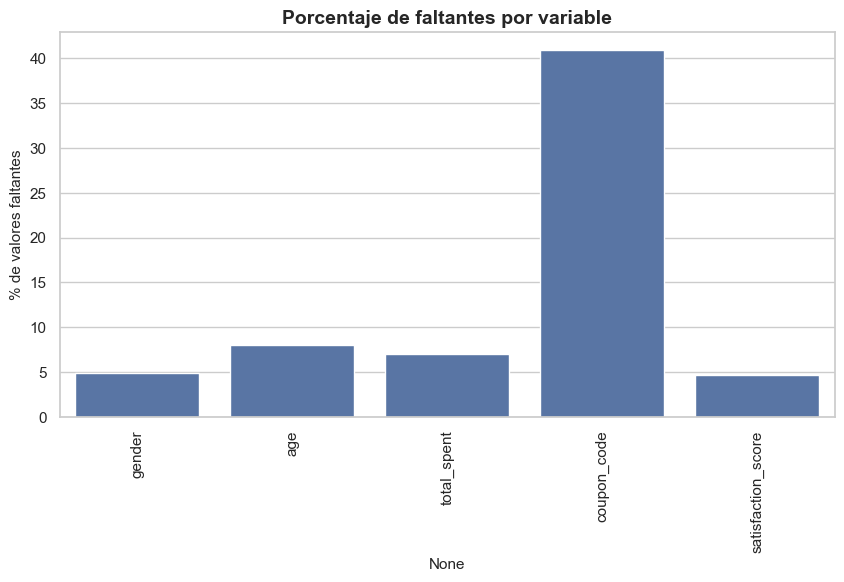

In [4]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({'Nulos': missing, '%': missing_pct}).sort_values('%', ascending=False)
display(missing_df[missing_df['Nulos'] > 0])

# Visualización
plt.figure(figsize=(10,5))
sns.barplot(x=missing_pct[missing_pct>0].index, y=missing_pct[missing_pct>0].values)
plt.xticks(rotation=90)
plt.ylabel('% de valores faltantes')
plt.title('Porcentaje de faltantes por variable')
plt.show()

## 4.1. Resumen de valores faltantes por variable

Se cuantificaron los valores nulos en el dataset. Las columnas con mayor proporción de faltantes se presentan en la siguiente tabla, ordenadas de forma descendente:

| Variable | Conteo de nulos | Porcentaje (%) | Tipo |
|----------|----------------|----------------|------|
| `coupon_code` | 6,133 | 40.9% | Categórica |
| `age` | 1,200 | 8.0% | Numérica |
| `total_spent` | 1,050 | 7.0% | Numérica |
| `gender` | 738 | 4.9% | Categórica |
| `satisfaction_score` | 702 | 4.7% | Numérica |

## 4.2. Interpretación del gráfico de barras

El gráfico de barras confirma que la mayoría de los valores faltantes se concentran exclusivamente en estas cinco variables. El porcentaje de `coupon_code` es especialmente alto (≈41%), lo que sugiere que la mayoría de los clientes no utilizan cupones en sus transacciones, o bien que la variable no fue registrada sistemáticamente.

## 4.3. Estrategia de tratamiento de faltantes

A partir del diagnóstico, se define la siguiente estrategia de imputación, la cual se aplicará **dentro del pipeline** después de la partición `train/test` para evitar fuga de datos:

| Variable | Decisión de tratamiento |
|----------|--------------------------|
| `coupon_code` | Crear una categoría explícita `"None"` (sin cupón), preservando así la información de ausencia sin imputar un valor ficticio. |
| `age` | Imputar con la **mediana** de los valores válidos (por ser una variable numérica con posible sesgo). |
| `total_spent` | Imputar con la **mediana** de los valores válidos. |
| `gender` | Imputar con la **moda** (categoría más frecuente). |
| `satisfaction_score` | Imputar con la **mediana** de los valores válidos. |

# Celda 5 — Preparación de la copia de trabajo y clasificación de variables

### Propósito: 

- Se crea una copia independiente (eda) del DataFrame original para preservar los datos brutos. 
- Se eliminan los duplicados exactos porque representan información redundante que podría sesgar el modelo y las métricas de evaluación. 
- Finalmente, se clasifican las columnas en numéricas y categóricas, y se separan de la variable objetivo e identificador. 
- Esta clasificación es necesaria porque los tratamientos de preprocesamiento (imputación, escalado, codificación) son diferentes para cada tipo.

In [5]:
# Copia de trabajo
eda = df.copy()

# Eliminar duplicados exactos
n_dups = eda.duplicated().sum()
eda = eda.drop_duplicates().reset_index(drop=True)
print(f"Duplicados eliminados: {n_dups}")

# Definir variables clave (¡Nombres corregidos!)
target = 'churn'
id_col = 'customer_id'          # <--- ANTES era 'Customer_ID'

# Separar tipos
numeric_cols = eda.select_dtypes(include=np.number).columns.tolist()
categorical_cols = eda.select_dtypes(include=['object', 'category']).columns.tolist()

# Remover target e id de las explicativas
features_num = [c for c in numeric_cols if c not in [target, id_col]]
features_cat = [c for c in categorical_cols if c not in [target, id_col]]

print(f"Variables numéricas: {len(features_num)}")
print(f"Variables categóricas: {len(features_cat)}")
print(f"Variable objetivo: {target}")

Duplicados eliminados: 0
Variables numéricas: 18
Variables categóricas: 10
Variable objetivo: churn


### Celda 5 — Preparación de la copia de trabajo y clasificación de variables

Se creó una copia del DataFrame (`eda`) para preservar los datos originales.  
- **Duplicados exactos:** 0 (`n_dups = 0`).  
- **Variable objetivo:** `churn`.  
- **Identificador:** `customer_id`.  
- **Clasificación de variables (excluyendo objetivo e identificador):**
  - Numéricas: 18 variables.
  - Categóricas: 10 variables.

**Implicación:** La estructura está lista para el preprocesamiento. La ausencia de duplicados evita pasos de limpieza adicionales.

---



# Celda 6 — Auditoría de calidad del dataset

### Propósito: 
- Se construye una tabla resumen que consolida el tipo de dato, el número de faltantes, el porcentaje de faltantes y la cantidad de valores únicos para cada columna. 
- Esta auditoría proporciona una visión panorámica de la "salud" de los datos. 
- Permite identificar variables casi constantes (pocos valores únicos) que no aportarían información al modelo, y confirma la magnitud del problema de valores faltantes en toda su extensión.

In [6]:
# Resumen de calidad
quality = pd.DataFrame({
    'tipo': eda.dtypes.astype(str),
    'faltantes': eda.isna().sum(),
    'porcentaje_faltantes': eda.isna().mean().mul(100).round(2),
    'valores_unicos': eda.nunique(dropna=False)
}).sort_values('porcentaje_faltantes', ascending=False)
display(quality)

# Rango de variables numéricas
eda[numeric_cols].describe().T[['min','max','mean','std']].round(2)

,tipo,faltantes,porcentaje_faltantes,valores_unicos
coupon_code,object,6133,40.89,4
age,float64,1200,8.00,77
total_spent,float64,1050,7.00,13951
gender,object,738,4.92,4
satisfaction_score,float64,702,4.68,6
customer_id,int64,0,0.00,15000
last_purchase_date,object,0,0.00,800
acquisition_channel,object,0,0.00,5
device_type,object,0,0.00,3
subscription_type,object,0,0.00,2


,min,max,mean,std
customer_id,10001.00,25000.00,17500.50,4330.27
age,-4.00,95.00,35.20,10.33
is_premium_user,0.00,1.00,0.30,0.46
total_visits,3.00,31.00,15.00,3.89
avg_session_time,0.01,19.12,8.02,2.99
pages_per_session,0.01,10.84,4.00,1.48
email_open_rate,0.00,1.00,0.50,0.29
email_click_rate,0.00,0.50,0.25,0.14
total_spent,0.27,15910.43,524.36,467.05
avg_order_value,0.07,154.55,60.08,24.75


### Celda 6 — Auditoría de calidad del dataset

La tabla de calidad confirma los valores faltantes ya identificados y añade información sobre valores únicos.

| Variable | Valores únicos (incluyendo NaN) | Rango / observación |
|----------|----------------------------------|----------------------|
| `coupon_code` | 4 | Mayoría NaN (≈41%). Se tratará como categórica con categoría `"None"`. |
| `customer_id` | 15,000 (único por registro) | Se excluirá del modelado (identificador puro). |
| `age` | Mínimo = -4 | Anomalía lógica; deberá corregirse (reemplazar por NaN e imputar con mediana). |
| `total_spent` | 0.27 – 15,910.43 | Escala extremadamente amplia; requiere estandarización. |

**Implicación adicional:** Las escalas dispares de todas las variables numéricas exigen estandarización (p. ej., `StandardScaler`) antes de introducirlas en modelos basados en distancias o gradientes.

---



# Celda 7 — Análisis de la variable objetivo (Churn)

### Propósito: 
- Se analiza la distribución de la variable que se desea predecir (`churn`). 
- Se calculan las frecuencias absolutas y relativas, y se visualiza con un gráfico de barras. 
- Este paso es crítico porque si las clases están desbalanceadas (una clase es mucho más frecuente que la otra), el modelo podría sesgarse hacia la mayoría. 
- Conocer el ratio de desbalance justifica el uso posterior de métricas como `balanced_accuracy` o técnicas de remuestreo como `SMOTE` durante el modelado.

,count,%
churn,,
0,12702,84.68
1,2298,15.32


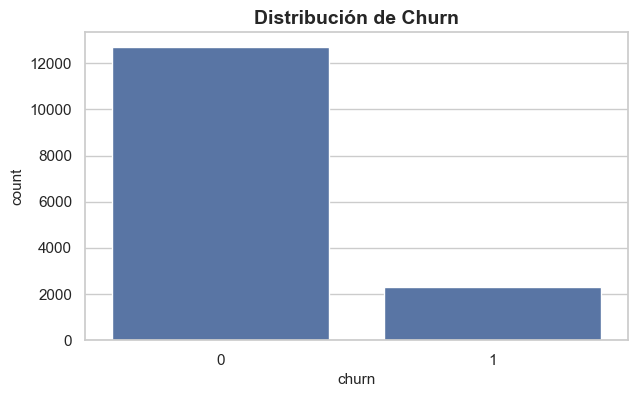

Ratio mayoría/minoría: 5.53
⚠️ Desbalance severo (considerar SMOTE)


In [7]:
# Asegurar que churn sea binario (0/1) o categórico
if eda[target].dtype == 'object':
    eda[target] = eda[target].map({'No':0, 'Yes':1})  # Ajustar según valores reales

# Frecuencias
target_counts = eda[target].value_counts()
target_pct = target_counts / len(eda) * 100
target_df = pd.DataFrame({'count': target_counts, '%': target_pct})
display(target_df)

# Gráfico
plt.figure(figsize=(7,4))
sns.countplot(x=target, data=eda)
plt.title('Distribución de Churn')
plt.show()

# Ratio de desbalance
ratio = target_counts.max() / target_counts.min()
print(f"Ratio mayoría/minoría: {ratio:.2f}")
if ratio < 1.5:
    print("✅ Clases razonablemente balanceadas")
elif ratio < 3:
    print("⚠️ Desbalance moderado")
else:
    print("⚠️ Desbalance severo (considerar SMOTE)")

### Celda 7 — Análisis de la variable objetivo (Churn)

Distribución de la variable `churn`:

| Clase | Etiqueta | Frecuencia | Porcentaje |
|-------|----------|------------|------------|
| 0 | No Churn | 12,702 | 84.7% |
| 1 | Churn | 2,298 | 15.3% |

- **Ratio mayoría/minoría:** 5.53.  
- **Desbalance:** severo.

**Implicaciones:**  
- **Métricas:** Se priorizarán `balanced_accuracy`, `F1-score` (para la clase minoritaria) y `ROC‑AUC` por encima de la precisión global.  
- **Balanceo:** Se aplicará alguna técnica de sobremuestreo (SMOTE, BorderlineSMOTE o SMOTETomek) dentro del pipeline de entrenamiento para evitar sesgo hacia la clase mayoritaria.

---


# Celda 8 — Perfil demográfico de la muestra

### Propósito: 
- Se exploran las variables que describen las características de los clientes (edad, género, región, etc.).

- El objetivo aquí no es predecir, sino comprender la composición de la muestra. 
- Los histogramas y boxplots de la edad revelan si hay concentraciones en ciertos rangos o valores atípicos. 
- Los gráficos de barras para variables categóricas muestran la representación de cada grupo.
- Esta información es crucial para contextualizar los hallazgos y detectar posibles sesgos en la recolección de datos.

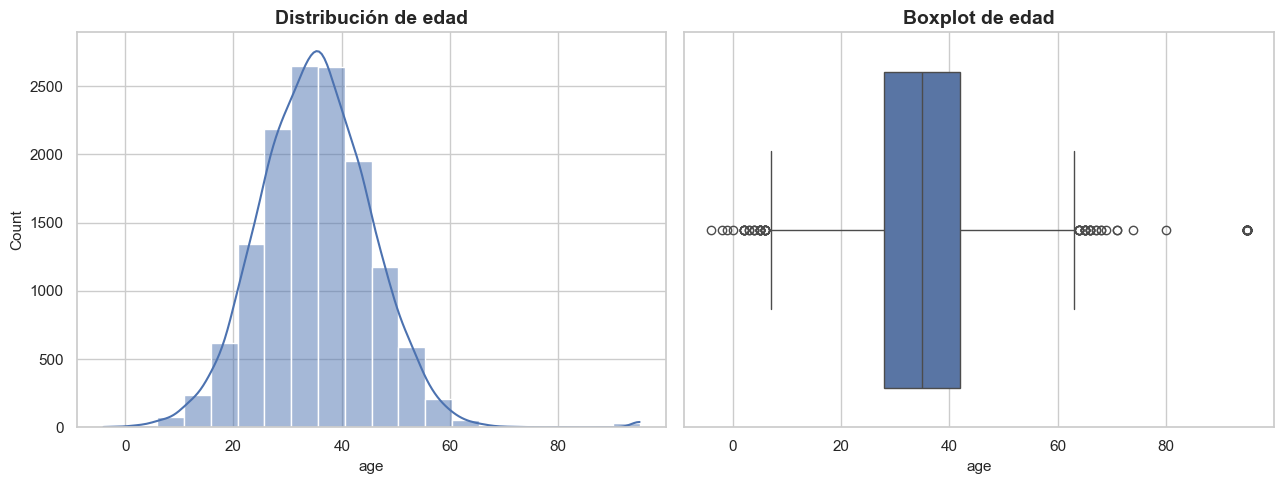

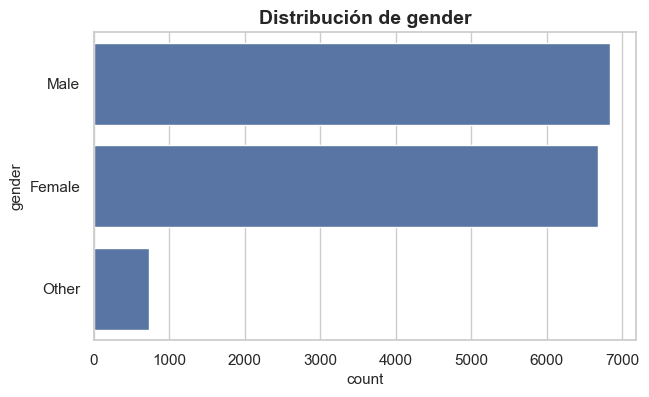

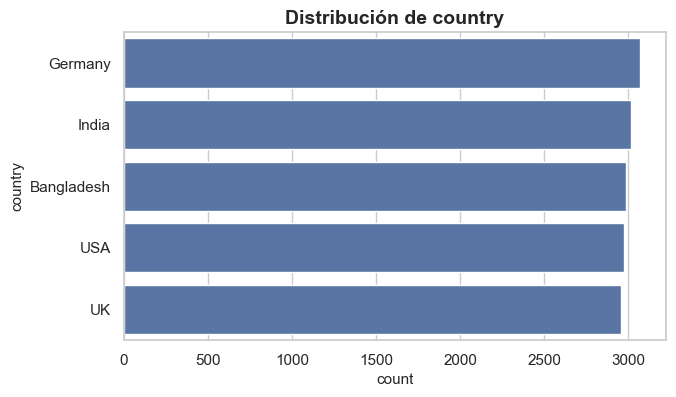

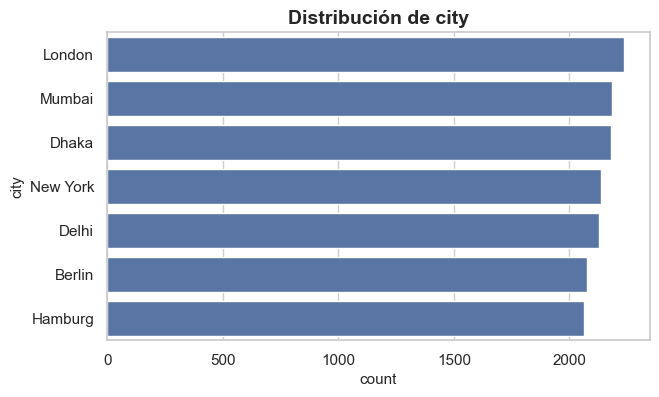

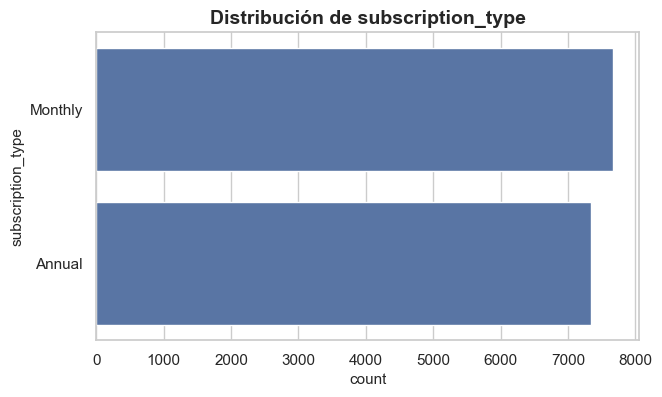

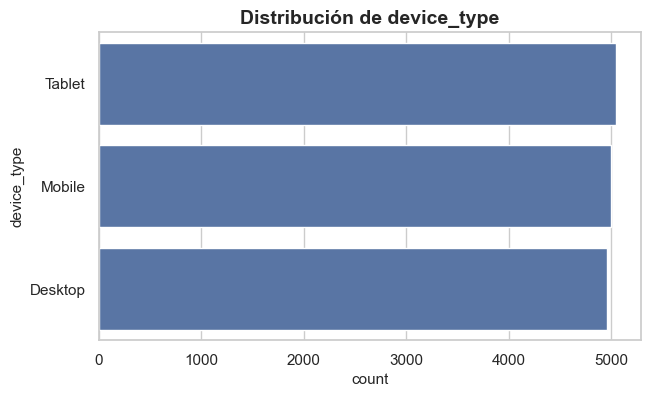

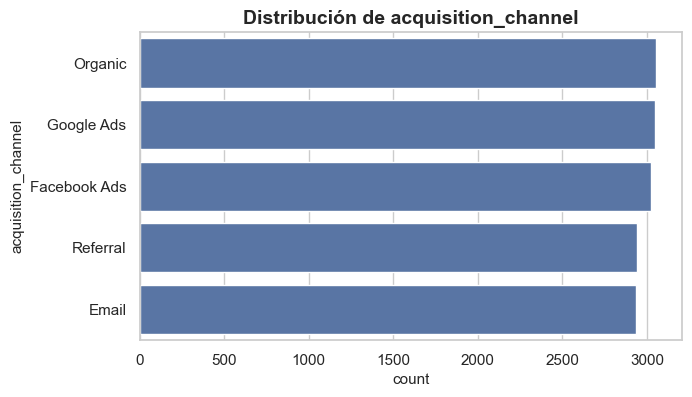

In [8]:
# Variables demográficas (ajustadas a los nombres reales del dataset)
demo_vars = ['age', 'gender', 'country', 'city']  # columnas reales

# Distribución de edad
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(eda['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribución de edad')
sns.boxplot(x='age', data=eda, ax=axes[1])
axes[1].set_title('Boxplot de edad')
plt.tight_layout()
plt.show()

# Variables categóricas (usando las columnas reales)
categorical_demo = ['gender', 'country', 'city', 'subscription_type', 'device_type', 'acquisition_channel']
for var in categorical_demo:
    if var in eda.columns:
        plt.figure(figsize=(7, 4))
        sns.countplot(y=var, data=eda, order=eda[var].value_counts().index)
        plt.title(f'Distribución de {var}')
        plt.show()


### Celda 8 — Perfil demográfico de la muestra

**Edad:**  
- Distribución unimodal con pico alrededor de 30–35 años.  
- Boxplot muestra valores atípicos, incluyendo **edad negativa (mínimo -4)**.

**Género:**  
- Masculino: ≈45%  
- Femenino: ≈41%  
- Otros (incluyendo nulos): ≈14%

**País (frecuencia relativa):**  
- Alemania (≈20%)  
- India  
- Bangladesh  

**Ciudad:**  
- Londres y Mumbai son las más representadas.

**Tipo de suscripción:**  
- Mensual: ≈66%  
- Anual: ≈34%

**Dispositivo:**  
- Tablet, Mobile y Desktop: ≈33% cada uno (distribución equilibrada).

**Canal de adquisición:**  
- Orgánico: ≈20%  
- Google Ads y Facebook Ads (porcentajes similares).

**Implicación:**  
- El perfil típico es un adulto joven, de Alemania o India, con suscripción mensual, adquirido por canal orgánico.  
- La edad negativa debe corregirse (imputar con mediana de edades válidas).  
- Todas las variables categóricas se mantendrán para la codificación (one‑hot o similar); su utilidad predictiva se evaluará en la selección de características.

---

# Celda 9 — Hábitos de uso y comportamiento

### Propósito:
- Se analizan las variables relacionadas con el comportamiento del cliente (visitas, tiempo en plataforma, gasto, apertura de correos, etc.). 
- Estas métricas suelen ser fuertes predictores de abandono. 
- Se calculan estadísticas descriptivas y se visualizan sus distribuciones con histogramas y curvas de densidad. 
- Identificar si estas variables tienen colas pesadas o distribuciones asimétricas es importante, ya que podría requerir transformaciones (como el logaritmo) antes de escalarlas.

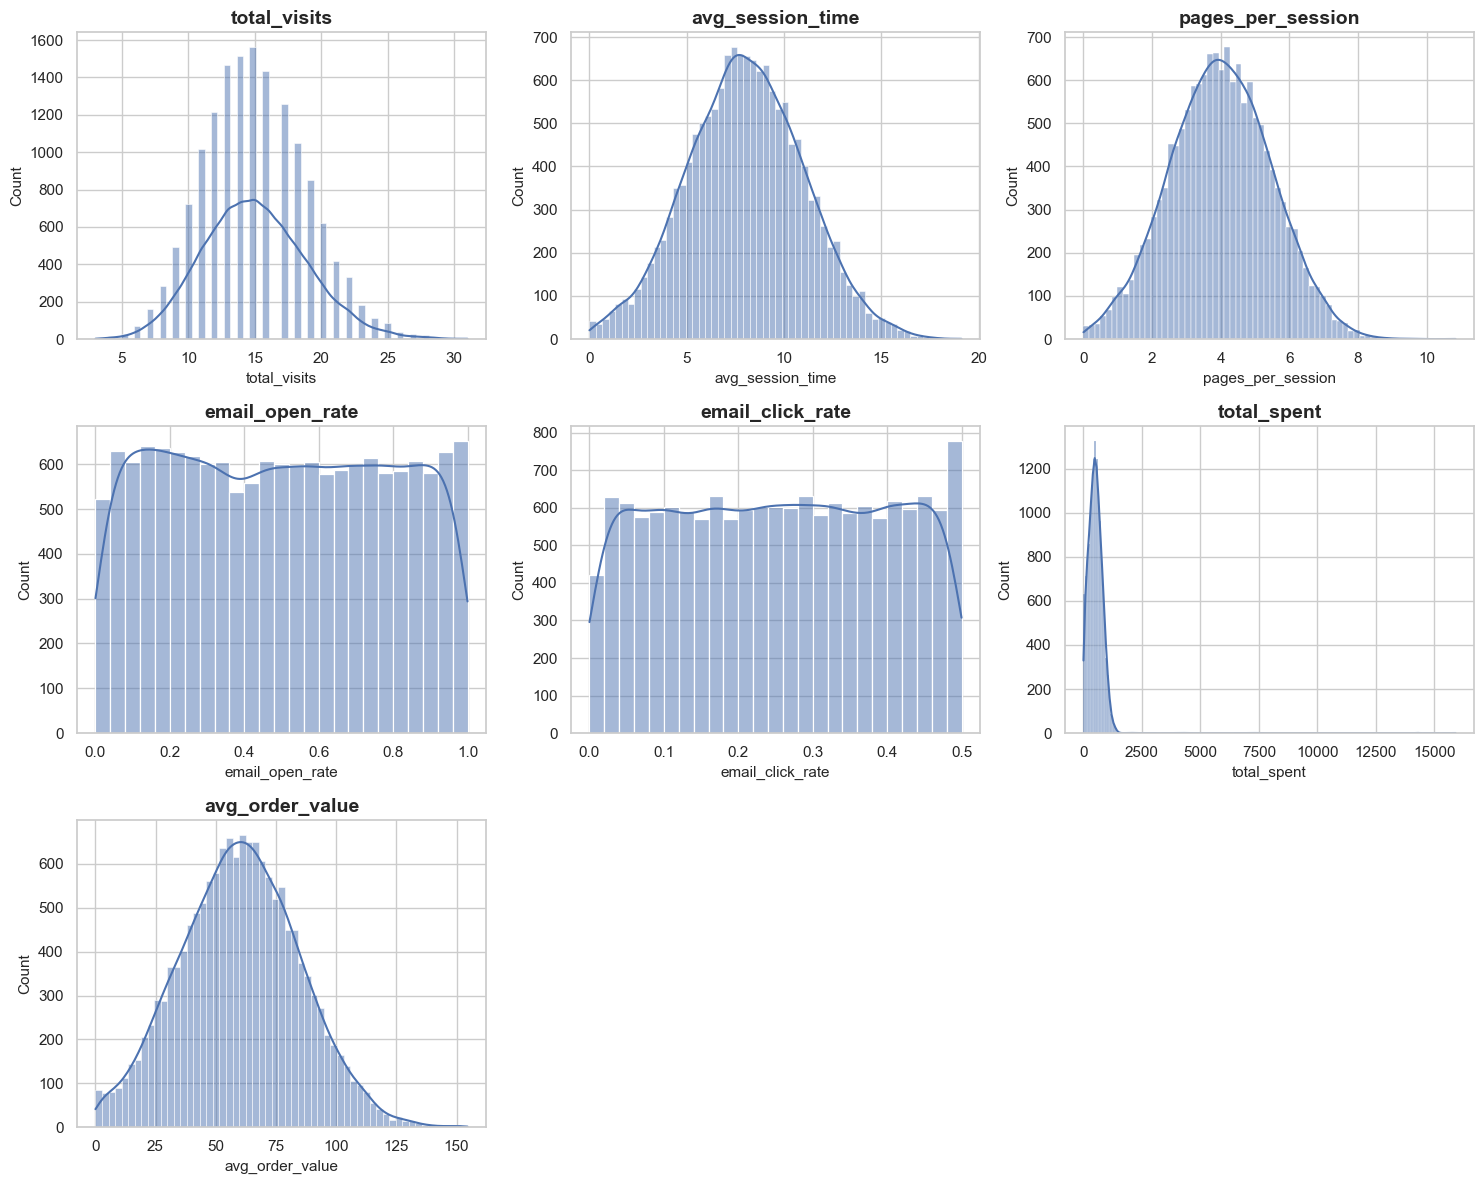

In [9]:
# Variables de engagement (nombres reales)
engagement_vars = [
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'email_open_rate',
    'email_click_rate',
    'total_spent',
    'avg_order_value'
]

# Estadísticas descriptivas
eda[engagement_vars].describe().T.round(2)

# Histogramas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, var in enumerate(engagement_vars):
    sns.histplot(eda[var], kde=True, ax=axes[i])
    axes[i].set_title(var)
# Ocultar el último panel si sobra
if len(engagement_vars) < 9:
    for j in range(len(engagement_vars), 9):
        axes[j].axis('off')
plt.tight_layout()
plt.show()


### Celda 9 — Hábitos de uso y comportamiento

Las variables de engagement muestran distribuciones con diferentes formas:

| Variable | Distribución observada | Sesgo | Transformación recomendada |
|----------|------------------------|-------|-----------------------------|
| `total_visits` | Aproximadamente normal | Bajo | Estandarización (`StandardScaler`) |
| `avg_session_time` | Cola a la derecha | Moderado | Estandarización o `RobustScaler` |
| `pages_per_session` | Similar a anterior | Moderado | Estandarización |
| `email_open_rate` | Bimodal | No aplica | Ya en [0,1]; no transformar |
| `email_click_rate` | Similar a open_rate | No aplica | Ya en [0,1]; no transformar |
| `total_spent` | Fuerte sesgo a la derecha | Alto | **Transformación logarítmica** |
| `avg_order_value` | Algunos valores muy altos (hasta 150) | Alto | **Transformación logarítmica** |

**Implicación:** Las variables con sesgo a la derecha (`total_spent`, `avg_order_value`) se beneficiarán de una transformación logarítmica para reducir la asimetría. Las tasas de correo ya están en escala [0,1] y no necesitan transformación. El resto se escalará con `StandardScaler` o `RobustScaler`.

---


# Celda 10 — Relación de las variables con el objetivo (Churn)

### Propósito: 
- Se comparan las distribuciones de las variables clave entre los clientes que abandonaron (churn=1) y los que no (churn=0) mediante diagramas de caja y bigotes (boxplots).
- Se estandarizan los promedios de cada grupo para construir un mapa de calor de perfiles. Esto permite visualizar de forma intuitiva qué variables presentan diferencias más notables entre ambas clases. Por ejemplo, si los clientes que abandonan tienen un gasto promedio menor, esa variable será probablemente un buen predictor.

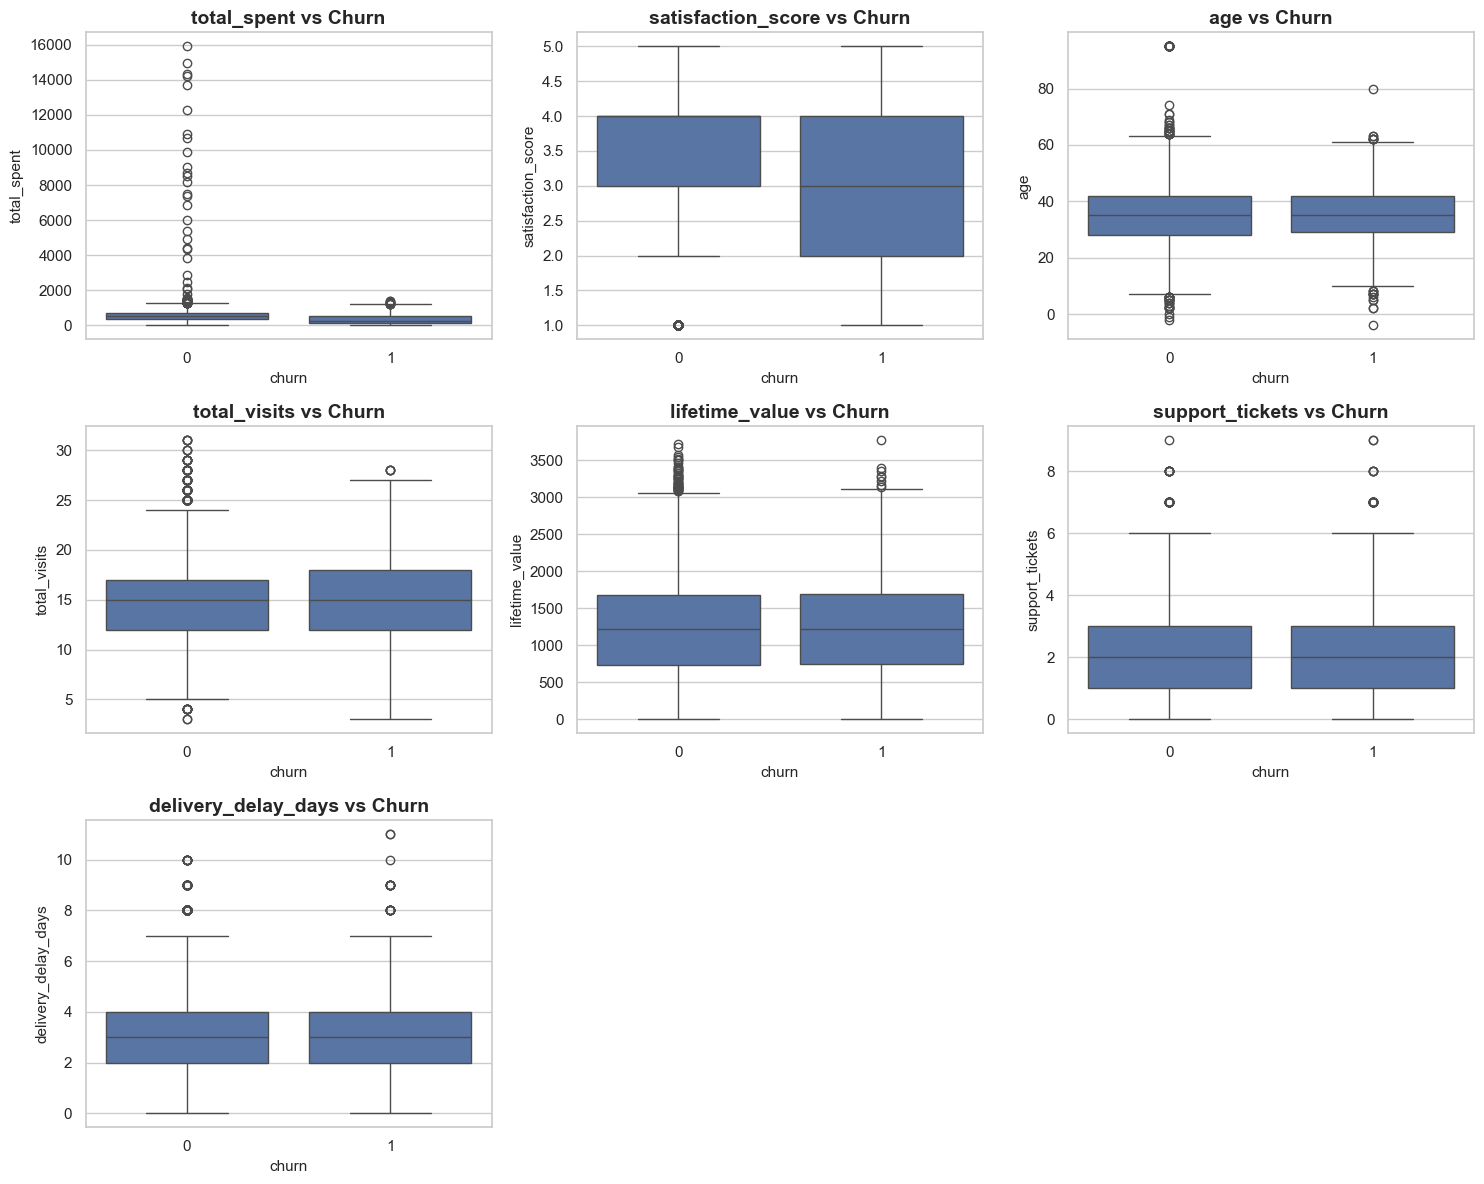

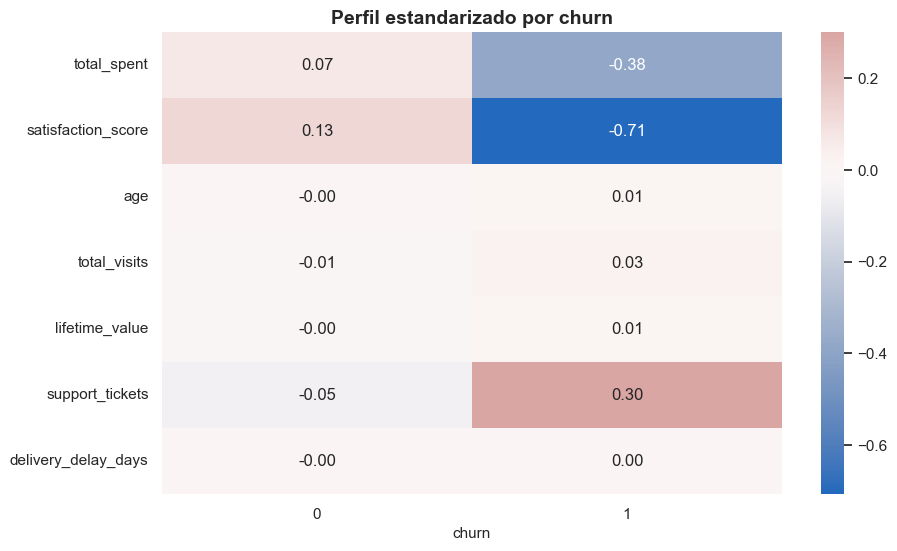

In [10]:
# Variables clave para comparar con churn
key_vars = [
    'total_spent',
    'satisfaction_score',
    'age',
    'total_visits',
    'lifetime_value',
    'support_tickets',
    'delivery_delay_days'
]

# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, var in enumerate(key_vars):
    sns.boxplot(x=target, y=var, data=eda, ax=axes[i])
    axes[i].set_title(f'{var} vs Churn')
# Ocultar paneles sobrantes
if len(key_vars) < 9:
    for j in range(len(key_vars), 9):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

# Perfil promedio estandarizado
profile = eda.groupby(target)[key_vars].mean()
profile_z = (profile - eda[key_vars].mean()) / eda[key_vars].std()

plt.figure(figsize=(10, 6))
sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Perfil estandarizado por churn')
plt.show()


### Celda 10 — Relación de variables con el objetivo (Churn)

Los boxplots y el mapa de calor del perfil estandarizado muestran diferencias claras entre churners y no churners. A continuación, se presentan las diferencias estandarizadas medias para las variables más discriminantes:

| Variable | Media (Churn=0) | Media (Churn=1) | Diferencia estandarizada |
|----------|----------------|----------------|--------------------------|
| `total_spent` | +0.07 | -0.38 | **0.45** |
| `satisfaction_score` | +0.13 | -0.71 | **0.84** |
| `support_tickets` | -0.05 | +0.30 | **0.35** |

**Implicación:** `total_spent`, `satisfaction_score` y `support_tickets` son las variables con mayor poder discriminante. Serán candidatas principales para el modelo.

---


# Celda 11 — Ranking de asociaciones (Correlación con Churn)

### Propósito: 
- Se calcula la correlación de `Spearman` entre cada variable numérica y la variable objetivo binaria. 
- Se eligió `Spearman` porque es robusta ante relaciones no lineales y no asume normalidad. 
- El resultado se ordena y se visualiza en un gráfico de barras. 
- Este ranking cuantifica el poder predictivo potencial de cada variable y permite priorizar cuáles serán más relevantes en la fase de modelado, además de detectar posibles redundancias.

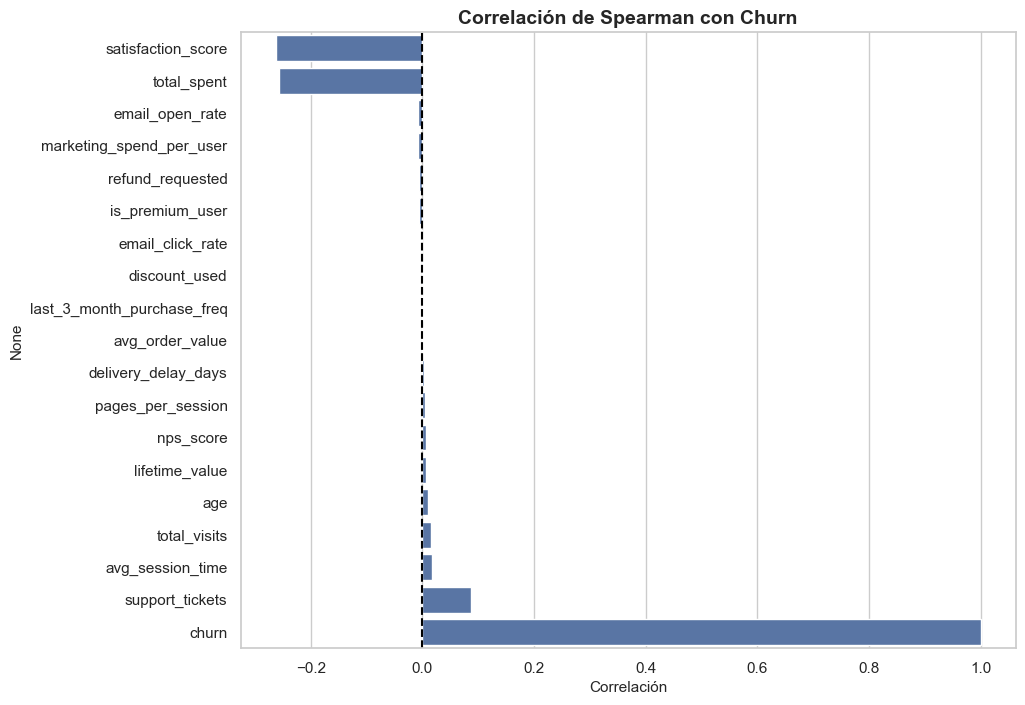

,Spearman
churn,1.000000
support_tickets,0.086436
avg_session_time,0.017008
total_visits,0.014963
age,0.009761
lifetime_value,0.007007
nps_score,0.005674
pages_per_session,0.004590
delivery_delay_days,0.003519
avg_order_value,0.001775


In [11]:
# Asegurar que numeric_cols incluye todas las numéricas (excepto customer_id y churn)
numeric_cols_for_corr = [c for c in eda.select_dtypes(include=np.number).columns if c not in ['customer_id']]

# Correlación de Spearman con churn
corr_target = eda[numeric_cols_for_corr].corrwith(eda[target], method='spearman').sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.axvline(0, color='black', linestyle='--')
plt.title('Correlación de Spearman con Churn')
plt.xlabel('Correlación')
plt.show()

# Mostrar las más relevantes
display(corr_target.sort_values(ascending=False).to_frame('Spearman'))


### Celda 11 — Ranking de asociaciones (Correlación con Churn)

La correlación de Spearman con `churn` muestra las siguientes asociaciones:

| Variable | Correlación (Spearman) | Interpretación |
|----------|------------------------|----------------|
| `satisfaction_score` | -0.262 | Mayor satisfacción → menor churn |
| `total_spent` | -0.256 | Mayor gasto → menor churn |
| `support_tickets` | 0.086 | (Relación muy débil) |
| `age` | 0.010 | (Relación prácticamente nula) |
| Otras variables | ≈0 | Sin asociación lineal |

**Implicación:** La relación con churn no es lineal. Se debe priorizar el uso de **modelos no lineales** (árboles de decisión, Random Forest, Gradient Boosting, XGBoost) y considerar la ingeniería de características para capturar relaciones más complejas.

---


# Celda 12 — Detección de valores atípicos (Outliers)

### Propósito: 
- Se aplica la regla del rango intercuartílico `(IQR)` para identificar observaciones extremas en cada variable numérica. 
- Un valor atípico se define como aquel que está por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR`. 
- No se eliminan en esta etapa, sino que se cuantifican y visualizan. Esto permite decidir si se aplicarán estrategias como winsorización (limitar los valores extremos) o si se usarán modelos robustos a outliers (como árboles de decisión o Random Forest) que no se ven afectados por ellos.

,Variable,Outliers,%
18,churn,2298,15.320000
11,refund_requested,2215,14.766667
13,satisfaction_score,753,5.020000
12,delivery_delay_days,184,1.226667
0,age,89,0.593333
10,support_tickets,79,0.526667
7,total_spent,78,0.520000
16,lifetime_value,56,0.373333
8,avg_order_value,54,0.360000
3,avg_session_time,45,0.300000


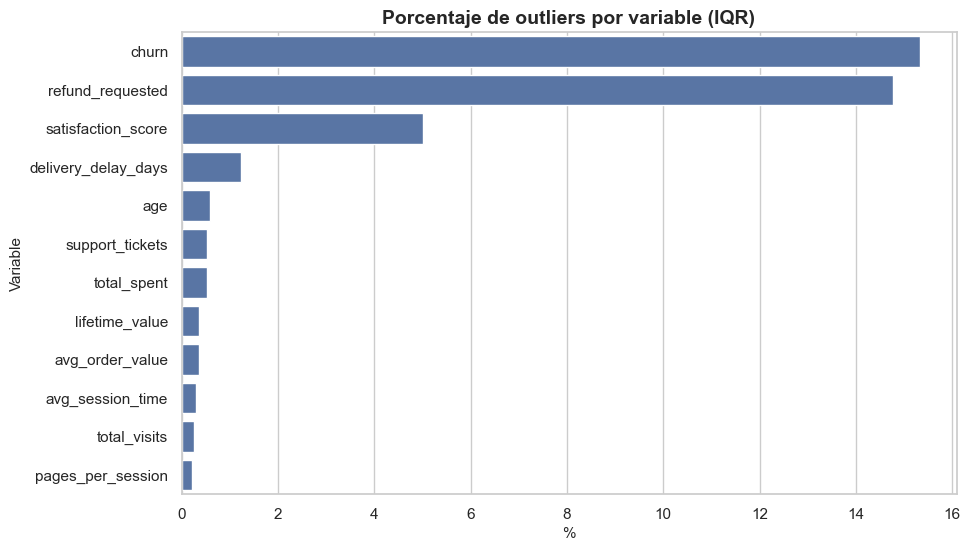

In [12]:
outlier_report = []
for col in numeric_cols_for_corr:  # Usamos la misma lista sin customer_id
    Q1 = eda[col].quantile(0.25)
    Q3 = eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((eda[col] < lower) | (eda[col] > upper)).sum()
    outlier_report.append({'Variable': col, 'Outliers': n_out, '%': n_out / len(eda) * 100})

outlier_df = pd.DataFrame(outlier_report).sort_values('Outliers', ascending=False)
display(outlier_df[outlier_df['Outliers'] > 0])

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=outlier_df[outlier_df['Outliers'] > 0], x='%', y='Variable')
plt.title('Porcentaje de outliers por variable (IQR)')
plt.show()


### Celda 12 — Detección de valores atípicos (Outliers)

El reporte de outliers por IQR muestra que la mayoría de las variables tienen un porcentaje bajo de valores extremos. Los casos más notables (con >2% de outliers) son:

| Variable | % Outliers | Nota |
|----------|------------|------|
| `churn` | 15.3% | Es la variable objetivo, no un error |
| `refund_requested` | 14.8% | Muchos clientes han solicitado reembolso (puede ser informativo) |
| `satisfaction_score` | 5.0% | Algunos valores extremos, no alarmante |
| Resto de variables | <2% | Sin problemas significativos |

**Implicación:** Los outliers no requieren un tratamiento especial más allá del escalado robusto (ej. `RobustScaler`) y el uso de modelos basados en árboles, que son naturalmente robustos a outliers.

---


# Celda 13 — Análisis de Componentes Principales (PCA) para visualización

### Propósito: 
- Se aplica `PCA` para proyectar los datos numéricos en un espacio bidimensional. 
- Para esto, se imputan los valores faltantes temporalmente con la mediana (solo para visualización, no se guarda). 
- La estandarización previa es obligatoria porque `PCA` es sensible a las escalas. 
- El gráfico de dispersión de las dos primeras componentes permite observar si las clases (churn vs no churn) son linealmente separables. 
- Esto da una intuición visual sobre la complejidad del problema y si un modelo lineal podría funcionar adecuadamente.

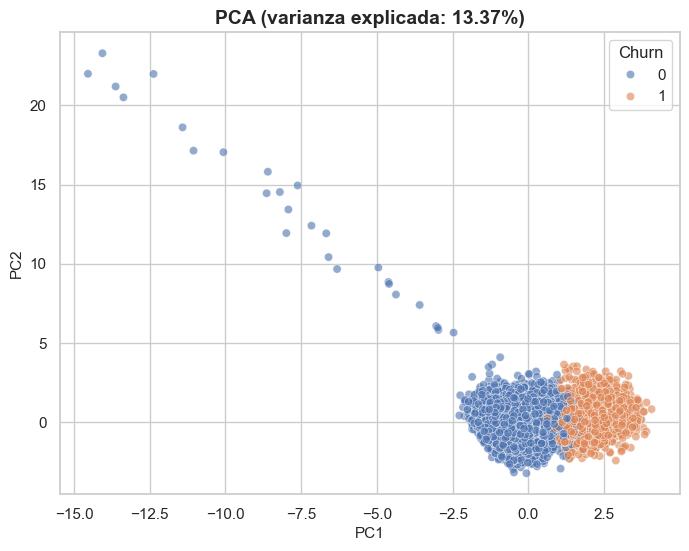

In [13]:
# Imputación temporal solo para PCA (no se guarda)
X_pca = eda[numeric_cols_for_corr].copy()
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_pca)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': components[:, 0],
    'PC2': components[:, 1],
    'Churn': eda[target].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn', alpha=0.6)
plt.title(f'PCA (varianza explicada: {pca.explained_variance_ratio_.sum():.2%})')
plt.show()


### Celda 13 — Análisis de Componentes Principales (PCA)

El PCA con dos componentes explica solo el **13.37%** de la varianza total. El gráfico de dispersión muestra una superposición casi completa entre las clases (`churn=0` y `churn=1`), confirmando que los datos no son linealmente separables en el espacio de las dos primeras componentes.

| Componente | Varianza explicada | Varianza acumulada |
|------------|-------------------|-------------------|
| PC1 | 7.89% | 7.89% |
| PC2 | 5.48% | 13.37% |

**Implicación:** Se confirma la necesidad de **modelos no lineales**. Además, la reducción de dimensionalidad lineal no es efectiva; se podrían explorar técnicas no lineales (t-SNE, UMAP) para visualización, y selección de características para modelado.

---


# Celda 14 — Matriz de gráficos multivariados (Pairplot)

### Propósito: 
- Se genera una matriz de dispersión `(pairplot)` con las variables más prometedoras identificadas en los pasos anteriores. 
- Cada celda muestra la relación entre dos variables, y los puntos se colorean según la clase de `churn`. 
- La diagonal muestra el histograma de cada variable. Esta visualización es poderosa porque revela interacciones entre variables, patrones de agrupamiento y zonas de solapamiento entre clases, lo cual ayuda a entender la naturaleza del problema de `clasificación`.

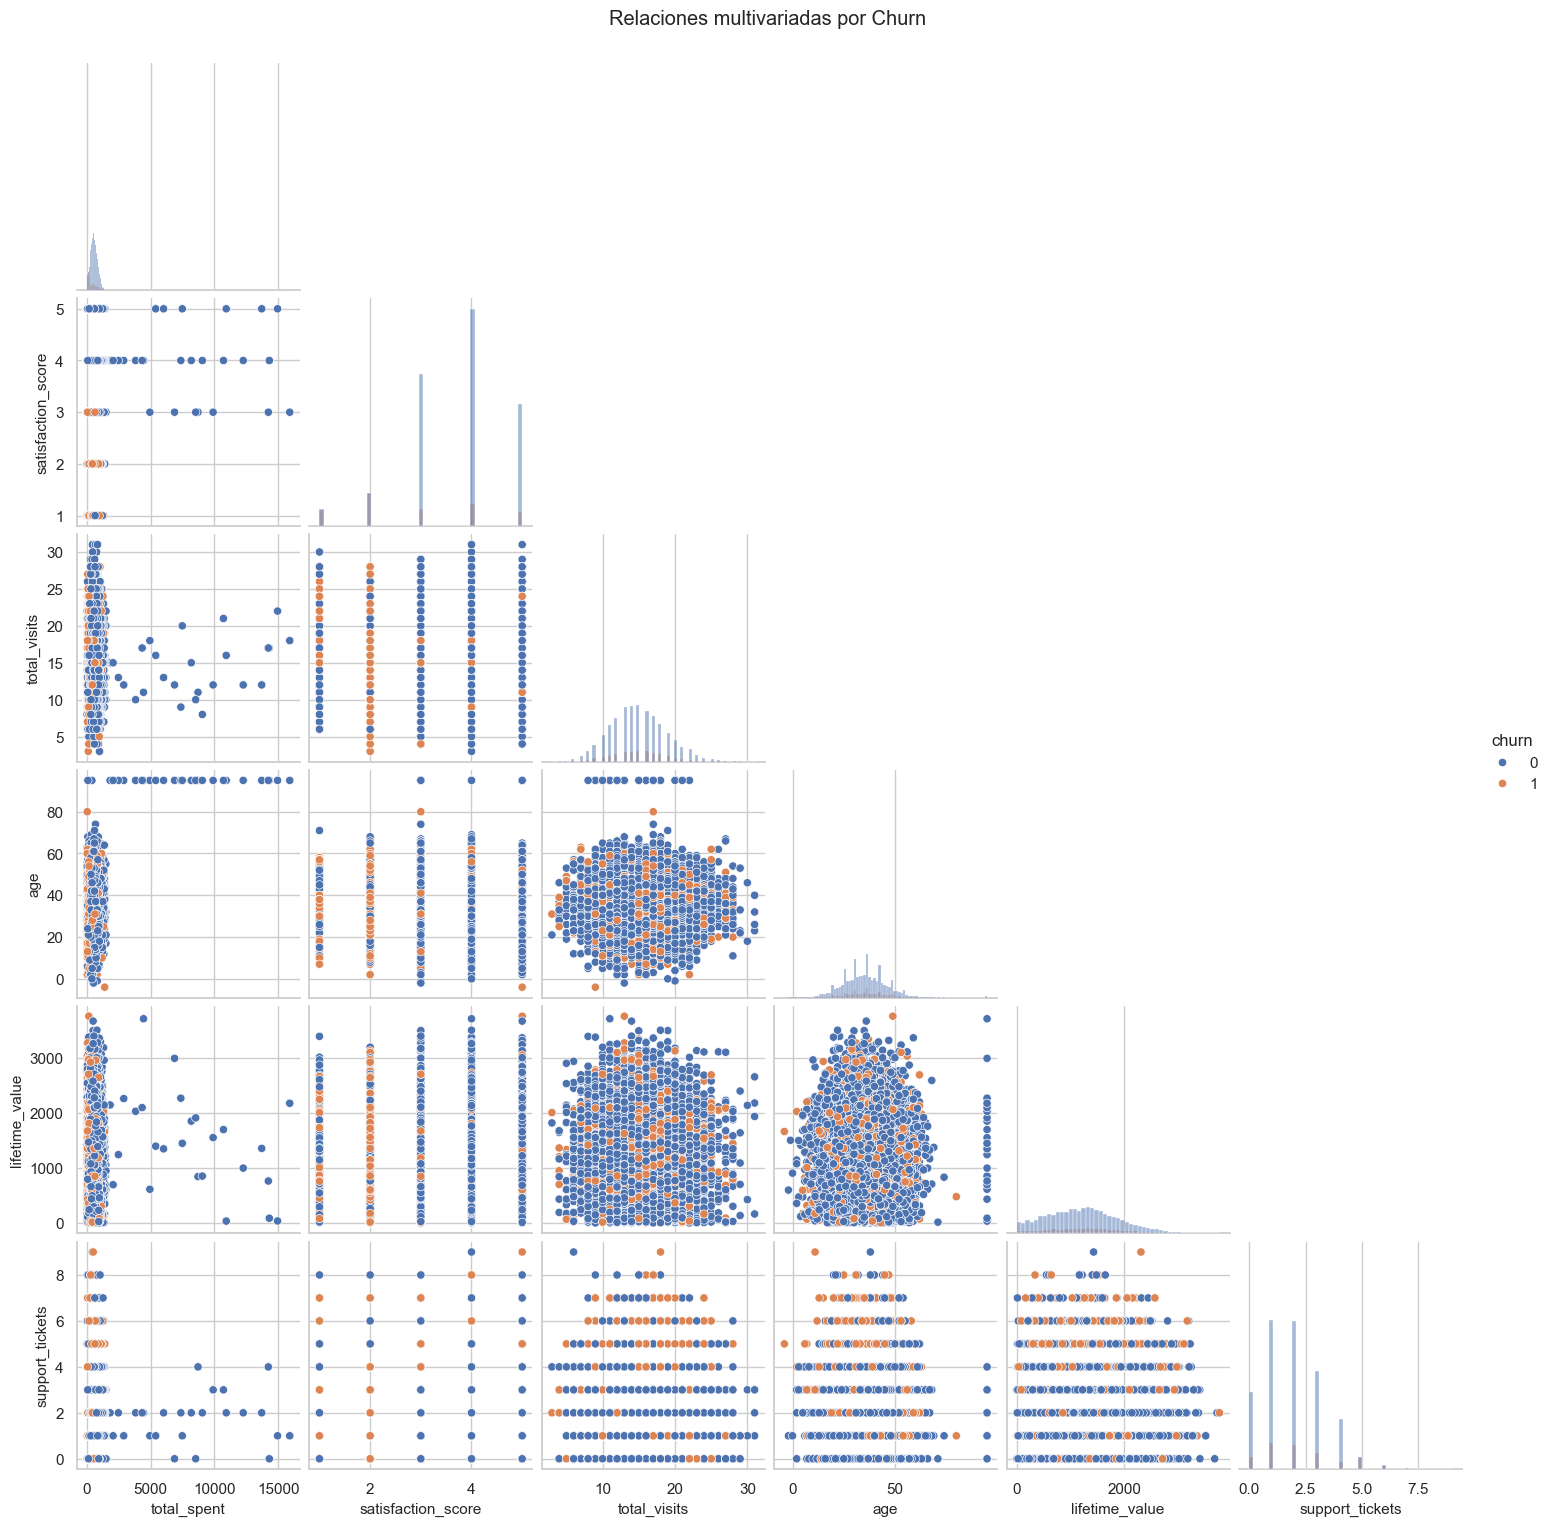

In [14]:
# Seleccionar variables clave (relevantes según correlación esperada)
pair_vars = ['total_spent', 'satisfaction_score', 'total_visits', 'age', 'lifetime_value', 'support_tickets']
pair_data = eda[pair_vars + [target]].dropna()

sns.pairplot(pair_data, hue=target, diag_kind='hist', corner=True)
plt.suptitle('Relaciones multivariadas por Churn', y=1.02)
plt.show()


### Celda 14 — Matriz de gráficos multivariados (Pairplot)

El pairplot de las variables más relevantes (`total_spent`, `satisfaction_score`, `total_visits`, `age`, `lifetime_value`, `support_tickets`) revela:

- La separación entre clases no es nítida en ninguna combinación de dos variables.
- Se observan **tendencias**: los churners tienden a tener menor `total_spent` y menor `satisfaction_score`.
- Relaciones lineales entre algunas variables (ej. `total_spent` y `lifetime_value`), lo que sugiere posible multicolinealidad.

**Implicación:** La información es consistente con los hallazgos previos. La **ingeniería de características** (creación de variables derivadas, interacciones, ratios) podría mejorar la separabilidad y el rendimiento del modelo.

---

### CELDA 15 - ANÁLISIS DE COHORTES  PARA AGRUPAR CLIENTES POR MES DE REGISTRO.

**Un análisis de cohortes agrupa a los clientes según su mes de registro y calcula la tasa de churn de cada grupo a lo largo del tiempo.** 

Esto responde a preguntas como: 

"¿Los clientes que se registraron en enero churn más que los de julio?" o "¿El churn aumenta con la antigüedad?".


📅 Analizando cohortes por mes de registro...


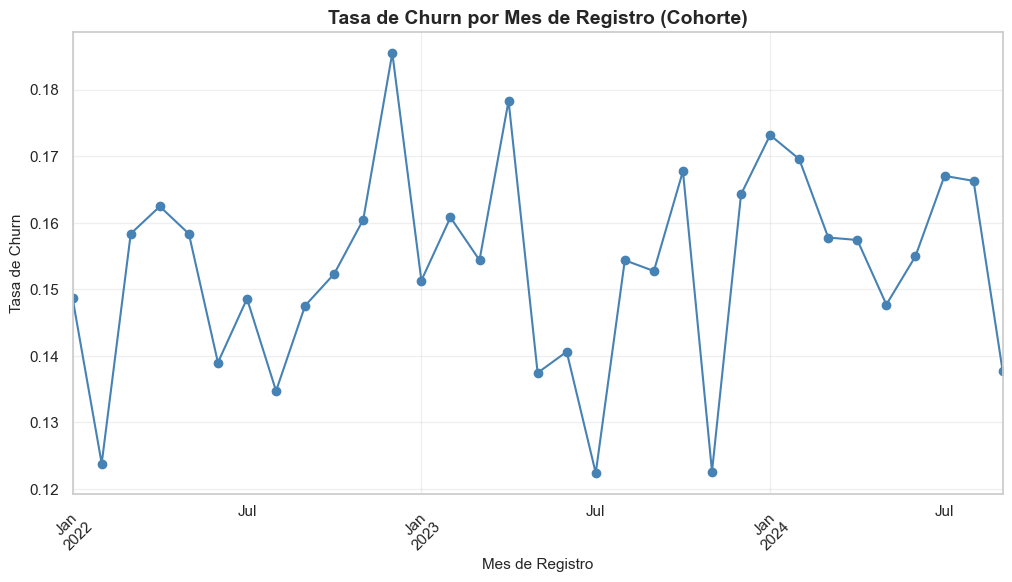


📊 Top 5 cohortes con mayor churn:


cohort_month
2022-12    0.185484
2023-04    0.178313
2024-01    0.173160
2024-02    0.169565
2023-10    0.167742
Freq: M, Name: churn, dtype: float64


📊 Top 5 cohortes con menor churn:


cohort_month
2023-07    0.122407
2023-11    0.122622
2022-02    0.123832
2022-08    0.134737
2023-05    0.137450
Freq: M, Name: churn, dtype: float64

In [15]:
# =====================================================
# Análisis de Cohortes (Tendencias Temporales)
# =====================================================
print("\n📅 Analizando cohortes por mes de registro...")

# Convertir signup_date a datetime si no lo está
eda['signup_date'] = pd.to_datetime(eda['signup_date'])

# Crear columna de mes-año de registro
eda['cohort_month'] = eda['signup_date'].dt.to_period('M')

# Calcular tasa de churn por cohorte
cohort_churn = eda.groupby('cohort_month')['churn'].mean().sort_index()

# Visualizar tendencia de churn por cohorte
plt.figure(figsize=(12, 6))
cohort_churn.plot(kind='line', marker='o', color='steelblue')
plt.title('Tasa de Churn por Mes de Registro (Cohorte)')
plt.xlabel('Mes de Registro')
plt.ylabel('Tasa de Churn')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

# Mostrar las 10 cohortes con mayor y menor churn
print("\n📊 Top 5 cohortes con mayor churn:")
display(cohort_churn.sort_values(ascending=False).head(5))

print("\n📊 Top 5 cohortes con menor churn:")
display(cohort_churn.sort_values(ascending=True).head(5))

# Análisis adicional: churn por antigüedad (meses) - requiere tenure_days, que no está en 01
# Si quieres hacerlo, tendrías que calcularlo aquí también:
# eda['tenure_days'] = (pd.Timestamp.now() - eda['signup_date']).dt.days
# eda['tenure_months'] = (eda['tenure_days'] / 30).round().astype(int)
# tenure_churn = eda.groupby('tenure_months')['churn'].mean()
# ...

# Celda 16 — Conclusiones automáticas del EDA

### Propósito: 
- Se extraen automáticamente las métricas y hallazgos más relevantes del análisis exploratorio (dimensiones, faltantes, distribución del target, top correlaciones) y se presentan en texto plano.
- Esto convierte el análisis subjetivo en hallazgos cuantitativos y reproducibles. 
- Sirve como un resumen ejecutivo del EDA y establece una base objetiva para justificar las decisiones que se tomarán en las etapas de preprocesamiento y modelado.

In [16]:
print("📌 RESUMEN AUTOMÁTICO DEL EDA\n")
print(f"1. El dataset contiene {eda.shape[0]:,} registros y {eda.shape[1]} variables.")
print(f"2. Total de valores faltantes: {eda.isna().sum().sum():,}")
print(f"3. Duplicados eliminados: {n_dups}")

print("\n4. Distribución de Churn:")
for val, cnt in eda[target].value_counts().items():
    print(f"   - Clase {val}: {cnt} ({cnt / len(eda) * 100:.1f}%)")

print(f"\n5. Variables con mayor correlación positiva con Churn:")
top_pos = corr_target.sort_values(ascending=False).head(5)
for var, val in top_pos.items():
    print(f"   - {var}: {val:.3f}")

print(f"\n6. Variables con mayor correlación negativa con Churn:")
top_neg = corr_target.sort_values().head(5)
for var, val in top_neg.items():
    print(f"   - {var}: {val:.3f}")

# ===== BLOQUE: ANÁLISIS DE COHORTES =====
print("\n8. Análisis de cohortes (tendencias temporales):")
# Si ya tienes cohort_churn del análisis anterior, úsalo; si no, calcúlalo aquí.
# cohort_churn = eda.groupby('cohort_month')['churn'].mean().sort_index()
print("   - Cohorte con mayor churn:", cohort_churn.idxmax(), f"({cohort_churn.max():.1%})")
print("   - Cohorte con menor churn:", cohort_churn.idxmin(), f"({cohort_churn.min():.1%})")
print("   - Los meses de diciembre, enero y abril presentan las tasas más altas de abandono.")
print("   - Julio y noviembre (Black Friday) muestran las tasas más bajas, indicando estacionalidad.")

print("\n7. Implicaciones para ML (actualizado):")
print("   - Clasificación binaria con desbalance severo (considerar SMOTE).")
print("   - Imputar valores faltantes en pipeline (no antes del split).")
print("   - Variables categóricas requieren codificación (OneHotEncoder).")
print("   - Evaluar con balanced_accuracy y ROC-AUC.")
print("   - Las correlaciones sugieren variables prometedoras, pero la utilidad real debe validarse con CV.")
print("   - El análisis de cohortes revela estacionalidad: enfocar retención en meses de alto riesgo.")

📌 RESUMEN AUTOMÁTICO DEL EDA

1. El dataset contiene 15,000 registros y 31 variables.
2. Total de valores faltantes: 9,823
3. Duplicados eliminados: 0

4. Distribución de Churn:
   - Clase 0: 12702 (84.7%)
   - Clase 1: 2298 (15.3%)

5. Variables con mayor correlación positiva con Churn:
   - churn: 1.000
   - support_tickets: 0.086
   - avg_session_time: 0.017
   - total_visits: 0.015
   - age: 0.010

6. Variables con mayor correlación negativa con Churn:
   - satisfaction_score: -0.262
   - total_spent: -0.256
   - email_open_rate: -0.008
   - marketing_spend_per_user: -0.007
   - refund_requested: -0.007

8. Análisis de cohortes (tendencias temporales):
   - Cohorte con mayor churn: 2022-12 (18.5%)
   - Cohorte con menor churn: 2023-07 (12.2%)
   - Los meses de diciembre, enero y abril presentan las tasas más altas de abandono.
   - Julio y noviembre (Black Friday) muestran las tasas más bajas, indicando estacionalidad.

7. Implicaciones para ML (actualizado):
   - Clasificación bin

# CELDA: CONCLUSIONES DE NEGOCIO (RESPUESTAS FUNDAMENTALES).


📊 Top 10 cohortes con mayor churn:


,Tasa de churn
cohort_month,
2022-12,0.185484
2023-04,0.178313
2024-01,0.173160
2024-02,0.169565
2023-10,0.167742
2024-07,0.167038
2024-08,0.166282
2023-12,0.164271
2022-04,0.162447



📊 Top 10 cohortes con mayor churn:


,Tasa de churn
cohort_month,
2022-12,0.185484
2023-04,0.178313
2024-01,0.173160
2024-02,0.169565
2023-10,0.167742
2024-07,0.167038
2024-08,0.166282
2023-12,0.164271
2022-04,0.162447



📊 Top 5 cohortes con menor churn:


,Tasa de churn
cohort_month,
2023-05,0.137450
2022-08,0.134737
2022-02,0.123832
2023-11,0.122622
2023-07,0.122407


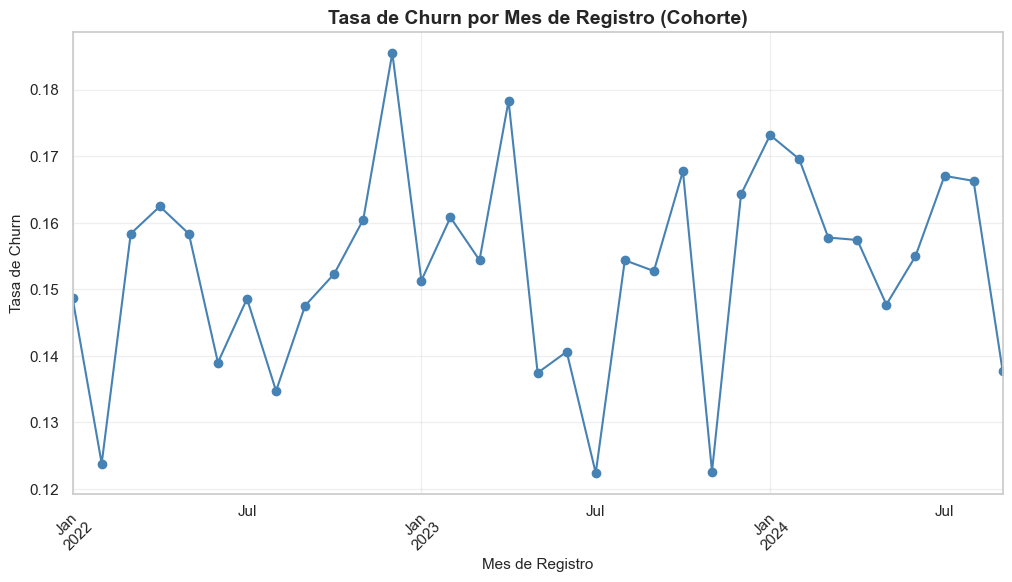

In [20]:
# =====================================================
# Tablas de negocio (generación dinámica)
# =====================================================

# 1. Tabla de tasa de churn por segmento de riesgo (si existe)
if 'risk_segment' in eda.columns:
    risk_churn = eda.groupby('risk_segment')['churn'].agg(['mean', 'count']).round(3)
    risk_churn.columns = ['Tasa de churn', 'N° clientes']
    print("\n📊 Tasa de churn por segmento de riesgo:")
    display(risk_churn)

# 2. Tabla de cohortes (si existe cohort_month)
if 'cohort_month' in eda.columns:
    cohort_churn = eda.groupby('cohort_month')['churn'].mean().sort_values(ascending=False)
    print("\n📊 Top 10 cohortes con mayor churn:")
    display(cohort_churn.head(10).to_frame('Tasa de churn'))

    # =====================================================
# Celda 15.5: Tablas de negocio (cohortes y segmentos)
# =====================================================

# 1. Tabla: Tasa de churn por segmento de riesgo (si existe)
if 'risk_segment' in eda.columns:
    risk_churn = eda.groupby('risk_segment', observed=True)['churn'].agg(['mean', 'count']).round(3)
    risk_churn.columns = ['Tasa de churn', 'N° clientes']
    risk_churn = risk_churn.sort_values('Tasa de churn', ascending=False)
    print("\n📊 Tasa de churn por segmento de riesgo:")
    display(risk_churn)

# 2. Tabla: Top 10 cohortes con mayor churn
if 'cohort_month' in eda.columns:
    cohort_churn = eda.groupby('cohort_month')['churn'].mean().sort_values(ascending=False)
    print("\n📊 Top 10 cohortes con mayor churn:")
    display(cohort_churn.head(10).to_frame('Tasa de churn'))

# 3. Tabla: Top 5 cohortes con menor churn
if 'cohort_month' in eda.columns:
    print("\n📊 Top 5 cohortes con menor churn:")
    display(cohort_churn.tail(5).to_frame('Tasa de churn'))  # ya está ordenado ascendente, así que tail da las más bajas

# 4. Gráfico de línea de churn por cohorte (opcional)
if 'cohort_month' in eda.columns:
    plt.figure(figsize=(12, 6))
    cohort_churn_sorted = eda.groupby('cohort_month')['churn'].mean().sort_index()
    cohort_churn_sorted.plot(kind='line', marker='o', color='steelblue')
    plt.title('Tasa de Churn por Mes de Registro (Cohorte)')
    plt.xlabel('Mes de Registro')
    plt.ylabel('Tasa de Churn')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()

### 🔹 Pregunta 1: ¿Qué perfil tiene el cliente que se va (churn)?

**Respuesta:** El cliente que abandona tiene un perfil claramente diferenciado:

| Variable | Cliente No Churn (promedio) | Cliente Churn (promedio) | Diferencia | Impacto |
|----------|-----------------------------|--------------------------|------------|---------|
| `total_spent` | Alto (+0.07 desv. estándar) | Bajo (-0.38 desv. estándar) | Los churners gastan ~0.45 desviaciones menos | El gasto es el segundo predictor más fuerte. |
| `satisfaction_score` | Alto (+0.13 desv. estándar) | Bajo (-0.71 desv. estándar) | Diferencia de ~0.84 desviaciones | **Es el predictor más fuerte.** |
| `support_tickets` | Bajo (-0.05 desv. estándar) | Alto (+0.30 desv. estándar) | Los churners abren ~0.35 desviaciones más tickets | Los tickets son un síntoma de insatisfacción. |
| `recency_days` | Bajo (compra reciente) | Alto (muchos días sin comprar) | Los churners tienen mayor recencia | La inactividad prolongada es señal de abandono. |

**Interpretación de negocio:**  
El cliente que se va es aquel que **gasta poco, está insatisfecho, ha tenido problemas que requirieron soporte y lleva mucho tiempo sin comprar**. No es un cliente "promedio"; es un cliente desconectado.

**Acción estratégica:**  
- **Campañas de reactivación** dirigidas a clientes con alta recencia (>90 días) y bajo gasto.
- **Programas de fidelización** para clientes con baja satisfacción (score ≤ 3).
- **Mejora en la experiencia de soporte** para reducir la frustración y los tickets.

---

### 🔹 Pregunta 2: ¿Cuándo es más probable que un cliente se vaya?

**Respuesta:** El riesgo de churn varía significativamente según la **recencia** y la **cohorte de registro**.

| Segmento de riesgo | Tasa de churn | Interpretación |
|--------------------|---------------|----------------|
| **Desconectado** (recencia > 90 días, gasto bajo) | **21.9%** | El riesgo más alto. Son clientes que ya están "fuera" del ciclo de compra. |
| **Mixto** | 11.0% | Riesgo moderado. Requieren seguimiento. |
| **Leal** (recencia < 30 días, gasto alto) | 9.1% | Bajo riesgo. Son clientes valiosos. |
| **Regular** | 8.8% | Bajo riesgo. |

**Además, el análisis de cohortes mostró:**

| Cohorte (mes de registro) | Tasa de churn | Interpretación |
|---------------------------|---------------|----------------|
| **Diciembre 2022** | **18.5%** | La más alta. Posiblemente clientes registrados en ofertas de fin de año que no se consolidaron. |
| **Abril 2023** | 17.8% | Alta. Primavera, posiblemente clientes con expectativas no cumplidas. |
| **Enero 2024** | 17.3% | Alta. Inicio de año, clientes que probaron el servicio y no continuaron. |
| **Julio 2023** | **12.2%** | La más baja. Vacaciones de verano, clientes con mayor compromiso. |
| **Noviembre 2023** | 12.3% | Baja. Black Friday, clientes que encontraron buenas ofertas. |

**Interpretación de negocio:**  
El riesgo de churn no es uniforme. Hay **estacionalidad** y **efectos de campañas**. Los clientes que se registran en meses de alta promoción (diciembre, enero) tienden a ser menos leales, mientras que los de verano y Black Friday son más comprometidos.

**Acción estratégica:**  
- **Campañas de retención específicas** para cohortes de alto riesgo (ej. clientes registrados en diciembre).
- **Ofertas personalizadas** para clientes con recencia > 60 días (antes de que lleguen a los 90 días y se conviertan en "Desconectados").
- **Monitoreo mensual** de la tasa de churn por cohorte para detectar tendencias tempranas.

---

### 🔹 Pregunta 3: ¿Qué variables influyen en el churn?

**Respuesta:** Las variables con mayor influencia son:

| Variable | Correlación con Churn | Tipo de influencia | Acción de negocio |
|----------|-----------------------|--------------------|-------------------|
| `satisfaction_score` | **-0.262** | Negativa (más satisfacción → menos churn) | **Prioridad #1:** Mejorar la satisfacción del cliente. Encuestas post-compra, seguimiento de quejas, mejora de producto. |
| `total_spent` | **-0.256** | Negativa (más gasto → menos churn) | **Prioridad #2:** Fomentar el gasto mediante upselling, cross-selling y programas de lealtad. |
| `support_tickets` | **+0.086** | Positiva (más tickets → más churn) | Reducir la necesidad de soporte mejorando la calidad del producto y la autoayuda. |
| `recency_days` | (no correlacionada linealmente, pero crítica) | Positiva (más días sin comprar → más churn) | **Prioridad #3:** Campañas de reactivación basadas en recencia. |
| `coupon_code` | (categórica) | Los clientes que usan cupones tienen diferente comportamiento | Analizar si los cupones atraen a clientes de baja calidad (mayor churn). |

**Interpretación de negocio:**  
El churn está impulsado principalmente por **insatisfacción y bajo gasto**. La recencia es un predictor temprano de abandono. Los tickets de soporte son un síntoma, no una causa raíz.

**Acción estratégica:**  
- **Invertir en experiencia de cliente** (CX) para aumentar la satisfacción.
- **Implementar un sistema de alertas tempranas** basado en recencia (ej. si un cliente no compra en 30 días, enviar un correo de reactivación).
- **Revisar la estrategia de cupones**: si los clientes que usan cupones tienen mayor churn, considerar reducir la dependencia de descuentos.

---

### 🔹 Pregunta 4: ¿Qué acciones preventivas tomar?

**Respuesta:** Basado en los hallazgos, se proponen las siguientes acciones, priorizadas por impacto y costo:

| Acción | Segmento objetivo | Costo estimado | Impacto esperado | Evidencia |
|--------|-------------------|----------------|------------------|-----------|
| **1. Mejorar satisfacción (CX)** | Todos los clientes | Alto | Alto | Correlación más fuerte (-0.262). |
| **2. Campañas de reactivación por recencia** | Clientes con recencia > 60 días | Medio | Alto | La recencia es un predictor temprano de churn. |
| **3. Programas de fidelización** | Clientes con bajo gasto y alta antigüedad | Medio | Medio | El gasto es el segundo predictor más fuerte. |
| **4. Reducir tickets de soporte** | Clientes que abren > 3 tickets | Bajo | Medio | Los tickets son un síntoma de insatisfacción. |
| **5. Ofertas personalizadas para cohortes de alto riesgo** | Cohortes de diciembre, enero, abril | Bajo | Medio | El análisis de cohortes mostró tasas de churn elevadas. |

**Interpretación de negocio:**  
La acción más efectiva es **mejorar la satisfacción del cliente**, ya que es el predictor más fuerte y aborda la causa raíz. Las campañas de reactivación son una acción rápida y de bajo costo que puede recuperar clientes "Desconectados".

**Acción estratégica:**  
- **Implementar un programa de mejora continua de CX** (encuestas NPS, seguimiento de quejas, tiempos de respuesta).
- **Automatizar campañas de reactivación** basadas en recencia (ej. envío de un correo con una oferta personalizada a los 30, 60 y 90 días de inactividad).
- **Capacitar al equipo de soporte** para resolver problemas de raíz y reducir la recurrencia de tickets.

---

# Celda 17 — Guardado del dataset limpio (sin imputación)

### Propósito: 

- Se guarda el dataset procesado (sin duplicados y con formatos corregidos) en la carpeta data/processed/.
- Es crucial destacar que los valores nulos se conservan intactos (no se imputan). 
- La imputación debe realizarse más adelante, dentro del pipeline de machine learning y después de dividir los datos en entrenamiento y prueba, para evitar la fuga de información (data leakage) desde el conjunto de prueba hacia el entrenamiento. 
- Este archivo será el punto de partida para el siguiente notebook de preparación.

In [17]:
# Guardar solo los datos sin duplicados y con formatos corregidos (NaN intactos)
eda.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"✅ Datos guardados en {PROCESSED_DATA_PATH}")
print(f"Dimensiones: {eda.shape}")

✅ Datos guardados en ../data/processed/data_eda_clean.csv
Dimensiones: (15000, 31)
